In [1]:
from google.colab import drive
drive.mount('/content/drive')

# --- Install dependencies ---
!pip install pandas~=2.0.3 \
            tqdm~=4.66.4 \
            torch~=2.3.0 \
            transformers~=4.41.1 \
            scikit-learn~=1.3.2 \
            datasets~=2.19.1 \
            matplotlib~=3.7.5 \
            nltk~=3.8.1 \
            tiktoken~=0.7.0 \
            lightning \
            faiss-gpu

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 139.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 59.7 MB/s eta 0:00:00


In [3]:
# LOAD DETECTOR MODELS

# Code taken from https://github.com/cong-zeng/ood-llm-detect
%cd /content/drive/MyDrive/ood-llm-detect/

import torch
from transformers import AutoTokenizer
from lightning import Fabric
import argparse
import numpy as np
from scipy.stats import norm
from types import SimpleNamespace

# These parameters are estimated by the test set
distrib_params = {'deepfake': {'mu0': 2.8207, 'sigma0': 1.188, 'mu1': 0.2149, 'sigma1': 2.3777},
                'M4': {'mu0': 2.8210, 'sigma0': 1.3977, 'mu1': 0.08976, 'sigma1': 2.79554},
                'raid': {'mu0': 3.3258, 'sigma0': 1.19811, 'mu1': 0.2563, 'sigma1': 2.39623}}
# Considering balanced classification that p(D0) equals to p(D1), we have
#   p(D1|x) = p(x|D1) / (p(x|D1) + p(x|D0))
# Copied from FastDetectGPT
def compute_prob_norm(x, mu0, sigma0, mu1, sigma1):
    pdf_value0 = norm.pdf(x, loc=mu0, scale=sigma0)
    pdf_value1 = norm.pdf(x, loc=mu1, scale=sigma1)
    prob = pdf_value1 / (pdf_value0 + pdf_value1)
    return prob

@torch.no_grad()
def predict_single(text, model, tokenizer, device="cuda", dataset_name="deepfake"):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    # 模型前向
    model.eval()
    loss, out, _, _ = model(encoded, 0, 0, torch.tensor([0]).to(device))
    # out 是概率分数（或 logits）
    prob = compute_prob_norm(out.cpu().numpy(),
                    distrib_params[dataset_name]['mu0'], distrib_params[dataset_name]['sigma0'],
                    distrib_params[dataset_name]['mu1'], distrib_params[dataset_name]['sigma1'])
    return prob.item()

def load_dsvdd_model(opt):
    # 根据 ood_type 选择模型定义
    if opt.ood_type == "deepsvdd":
        from src.deep_SVDD import SimCLR_Classifier_SCL
    elif opt.ood_type == "energy":
        from src.energy import SimCLR_Classifier_SCL
    elif opt.ood_type == "hrn":
        from src.hrn import SimCLR_Classifier_SCL
    else:
        raise ValueError("Only support deepsvdd, hrn and energy")

    fabric = Fabric(accelerator="cuda", devices=1)
    fabric.launch()
    if opt.ood_type == "hrn":
        model = SimCLR_Classifier_SCL(opt, opt.num_models, fabric)
    else:
        model = SimCLR_Classifier_SCL(opt, fabric)
    state_dict = torch.load(opt.model_path, map_location="cpu")
    model.load_state_dict(state_dict)
    model = model.cuda()
    tokenizer = model.model.tokenizer
    return model, tokenizer

def make_opt(device_num: int = 8,
             temperature: float = 0.07,
             a: float = 1.0,
             d: float = 1.0,
             nu: float = 0.1,
             objective: str = "one-class",
             out_dim: int = 128,
             only_classifier: bool = False,
             mode: str = "deepfake",
             ood_type: str = "deepsvdd",
             model_path: str = "xxx/model_best_gpt35.pth",
             model_name: str = "princeton-nlp/unsup-simcse-roberta-base"):
    """
    Construct an opt object equivalent to argparse.Namespace used by the original script.
    Use this to pass hyperparameters programmatically instead of via CLI.
    """
    return SimpleNamespace(
        device_num=device_num,
        temperature=temperature,
        a=a,
        d=d,
        nu=nu,
        objective=objective,
        out_dim=out_dim,
        only_classifier=only_classifier,
        mode=mode,
        ood_type=ood_type,
        model_path=model_path,
        model_name=model_name
    )

opt_deepfake = make_opt(model_path="/content/drive/MyDrive/ood-llm-detect/dsvdd_deepfake.pth",
               ood_type="deepsvdd",
               mode="deepfake",
               out_dim=768)

opt_raid = make_opt(model_path="/content/drive/MyDrive/ood-llm-detect/dsvdd_raid.pth",
               ood_type="deepsvdd",
               mode="raid",
               out_dim=768)

dsvdd_deepfake_model, dsvdd_deepfake_tokenizer = load_dsvdd_model(opt_deepfake)
dsvdd_raid_model, dsvdd_raid_tokenizer = load_dsvdd_model(opt_raid)

def llm_detection_dsvdd(text, model, tokenizer, opt):
    return predict_single(text, model, tokenizer, dataset_name=opt.mode)


/content/drive/MyDrive/ood-llm-detect


INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:
# Dataset NYT articles vs. diverse LLMs https://arxiv.org/html/2510.22874v1#S1

import os
import math
from datasets import load_dataset
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
SAMPLE_LIMIT = None          # set to an int to limit rows for speed (e.g., 2000), or None to use all
RANDOM_SEED = 42
OUTPUT_FIGURE = "/content/drive/MyDrive/parallel_corpus_detector_score_distributions_2x2.png"
BINS = 20
FIGSIZE = (20, 17)
RANGE = (0.0, 1.0)

# --- Load dataset ---
ds = load_dataset("browndw/human-ai-parallel-corpus", split="train")  # use 'train' split if available; adjust if different
ds_chunk_2 = ds.filter(lambda row: "@chunk_2" in str(row["doc_id"]))
ds_gpt = ds.filter(lambda row: "@gpt-4o-2024-08-06" in str(row["doc_id"]))
print(len(ds_chunk_2))
print(len(ds_gpt))

indices_human = np.arange(len(ds_chunk_2))
indices_gpt = np.arange(len(ds_gpt))

# --- Containers for scores ---
scores = {
    "Human_deepfake": [],
    "Human_raid": [],
    "GPT_deepfake": [],
    "GPT_raid": []
}

# --- Run detectors ---
print("Running detectors on selected columns. This may take a while depending on dataset size and model speed.")
for i in tqdm(indices_human, desc="Rows"):
    row = ds_chunk_2[int(i)]
    human_text = row["text"]

    # Skip empty texts to avoid meaningless predictions
    if human_text and human_text.strip():
        try:
            s_hd = llm_detection_dsvdd(human_text, dsvdd_deepfake_model, dsvdd_deepfake_tokenizer, opt_deepfake)
            s_hr = llm_detection_dsvdd(human_text, dsvdd_raid_model, dsvdd_raid_tokenizer, opt_raid)
        except Exception as e:
            # If a single prediction fails, log NaN and continue
            s_hd, s_hr = math.nan, math.nan
            print(f"Warning: detector error on Human row {i}: {e}")
    else:
        s_hd, s_hr = math.nan, math.nan
        print(f"Warning: no text on Human row {i}")

    # Ensure numeric and clipped to [0,1] if possible
    def sanitize_score(x):
        try:
            x = float(x)
            if np.isnan(x):
                return np.nan
            return float(np.clip(x, 0.0, 1.0))
        except Exception:
            return np.nan

    scores["Human_deepfake"].append(sanitize_score(s_hd))
    scores["Human_raid"].append(sanitize_score(s_hr))

for i in tqdm(indices_gpt, desc="Rows"):
    row = ds_gpt[int(i)]
    gpt_text = row["text"]

    # Skip empty texts to avoid meaningless predictions
    if gpt_text and gpt_text.strip():
        try:
            s_gd = llm_detection_dsvdd(gpt_text, dsvdd_deepfake_model, dsvdd_deepfake_tokenizer, opt_deepfake)
            s_gr = llm_detection_dsvdd(gpt_text, dsvdd_raid_model, dsvdd_raid_tokenizer, opt_raid)
        except Exception as e:
            # If a single prediction fails, log NaN and continue
            s_gd, s_gr = math.nan, math.nan
            print(f"Warning: detector error on GPT row {i}: {e}")
    else:
        s_gd, s_gr = math.nan, math.nan
        print(f"Warning: no text on GPT row {i}")

    # Ensure numeric and clipped to [0,1] if possible
    def sanitize_score(x):
        try:
            x = float(x)
            if np.isnan(x):
                return np.nan
            return float(np.clip(x, 0.0, 1.0))
        except Exception:
            return np.nan

    scores["GPT_deepfake"].append(sanitize_score(s_gd))
    scores["GPT_raid"].append(sanitize_score(s_gr))

# --- Convert to pandas Series and drop NaNs for plotting/stats ---
series = {k: pd.Series(v).dropna().astype(float) for k, v in scores.items()}

for k, s in series.items():
    print(f"{k}: count={len(s)}, mean={s.mean() if len(s)>0 else float('nan'):.4f}, median={s.median() if len(s)>0 else float('nan'):.4f}")


README.md:   0%|          | 0.00/58.5k [00:00<?, ?B/s]

text_data/hape-text_gpt-4o-2024-08-06.pa(…): reconstructing file:   0%|          |  0.00B / 17.6MB            

text_data/hape-text_gpt-4o-2024-08-06.pa(…): downloading bytes:           |  0.00B            

text_data/hape-text_gpt-4o-mini-2024-07-(…): reconstructing file:   0%|          |  0.00B / 18.9MB            

text_data/hape-text_gpt-4o-mini-2024-07-(…): downloading bytes:           |  0.00B            

...

Filter:   0%|          | 0/66320 [00:00<?, ? examples/s]

8290
8290
Running detectors on selected columns. This may take a while depending on dataset size and model speed.


Rows:   0%|          | 0/8290 [00:00<?, ?it/s]

Rows:   0%|          | 0/8290 [00:00<?, ?it/s]

Human_deepfake: count=8290, mean=0.3362, median=0.1850
Human_raid: count=8290, mean=0.2860, median=0.1477
GPT_deepfake: count=8290, mean=0.7467, median=0.8658
GPT_raid: count=8290, mean=0.3847, median=0.2348


Figure saved to /content/drive/MyDrive/parallel_corpus_detector_score_distributions_2x2.png


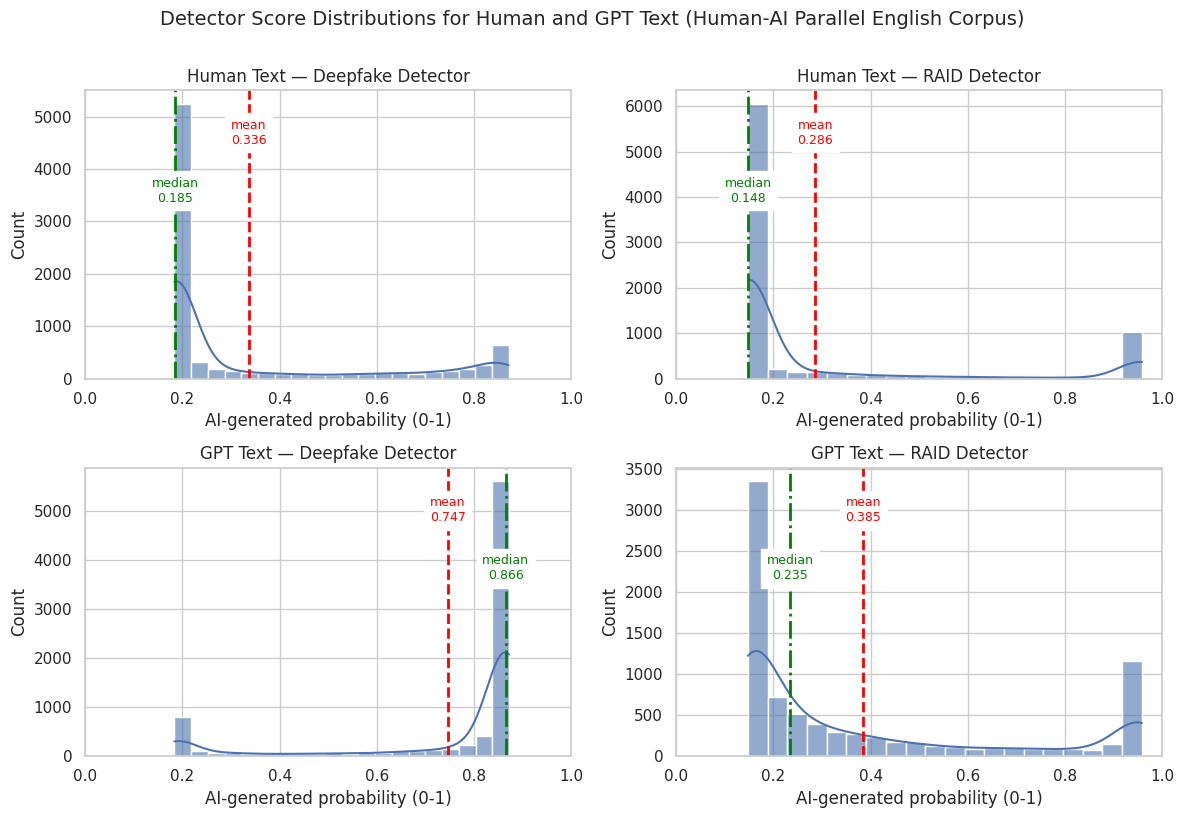

In [8]:
# --- Plotting 2x2 grid ---
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plot_configs = [
    ("Human Text — Deepfake Detector", "Human_deepfake"),
    ("Human Text — RAID Detector", "Human_raid"),
    ("GPT Text — Deepfake Detector", "GPT_deepfake"),
    ("GPT Text — RAID Detector", "GPT_raid"),
]

for ax, (title, key) in zip(axes, plot_configs):
    data = series.get(key, pd.Series(dtype=float))
    if data.empty:
        ax.text(0.5, 0.5, "No valid scores", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.set_xlim(RANGE)
        continue

    # Histogram with KDE
    sns.histplot(data, bins=BINS, kde=True, stat="count", ax=ax, color="#4C72B0", edgecolor=None, alpha=0.6)
    ax.set_xlim(RANGE)
    ax.set_ylim(bottom=0)

    # Mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"mean={mean_val:.3f}")
    ax.axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"median={median_val:.3f}")

    # Annotations
    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 0.9, f"mean\n{mean_val:.3f}", color="red", ha="center", va="top", fontsize=9, backgroundcolor="white")
    ax.text(median_val, ymax * 0.7, f"median\n{median_val:.3f}", color="green", ha="center", va="top", fontsize=9, backgroundcolor="white")

    ax.set_title(title)
    ax.set_xlabel("AI-generated probability (0-1)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.suptitle("Detector Score Distributions for Human and GPT Text (Human-AI Parallel English Corpus)", fontsize=14, y=1.02)
plt.subplots_adjust(top=0.92)

# Save and show
fig.savefig(OUTPUT_FIGURE, dpi=200, bbox_inches="tight")
print(f"Figure saved to {OUTPUT_FIGURE}")
plt.show()